In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

df_prices = pd.read_csv("matched_rows_with_zip_20260419.csv")
df_deaths = pd.read_csv("charge_master_ca_deathcounts.csv", low_memory=False)

df_prices["charge_numeric"] = pd.to_numeric(df_prices["charge_numeric"], errors="coerce")
df_deaths["Count"] = pd.to_numeric(df_deaths["Count"], errors="coerce")

In [16]:
price_zip = (
    df_prices.groupby("zip")["charge_numeric"]
    .mean()
    .reset_index()
    .rename(columns={"charge_numeric": "avg_price"})
)

price_zip.head()

,zip,avg_price
0,90012,2109.000000
1,90015,3657.750000
2,90017,2334.332500
3,90023,3006.500000
4,90027,2031.269091


In [17]:
death_2024 = df_deaths[
    (df_deaths["Year"] == 2024) &
    (df_deaths["Cause"] == "ALL") &
    (df_deaths["Strata"] == "Total Population")
][["ZIP_Code", "Count"]].drop_duplicates()

death_2024 = death_2024.rename(columns={
    "ZIP_Code": "zip",
    "Count": "total_deaths"
})

death_2024.head()

,zip,total_deaths
372960,90001,312.0
372988,90002,314.0
373016,90003,444.0
373044,90004,300.0
373072,90005,245.0


In [18]:
df_final = pd.merge(price_zip, death_2024, on="zip", how="inner")

df_final = df_final.dropna(subset=["avg_price", "total_deaths"])

df_final.head()

,zip,avg_price,total_deaths
0,90012,2109.000000,207.0
1,90015,3657.750000,91.0
2,90017,2334.332500,149.0
3,90023,3006.500000,289.0
4,90027,2031.269091,283.0


In [19]:
from scipy.stats import spearmanr

rho, pval = spearmanr(df_final["avg_price"], df_final["total_deaths"])

print("Spearman rho:", round(rho, 3))
print("p-value:", round(pval, 3))
print("ZIP codes:", len(df_final))

Spearman rho: 0.11
p-value: 0.051
ZIP codes: 315


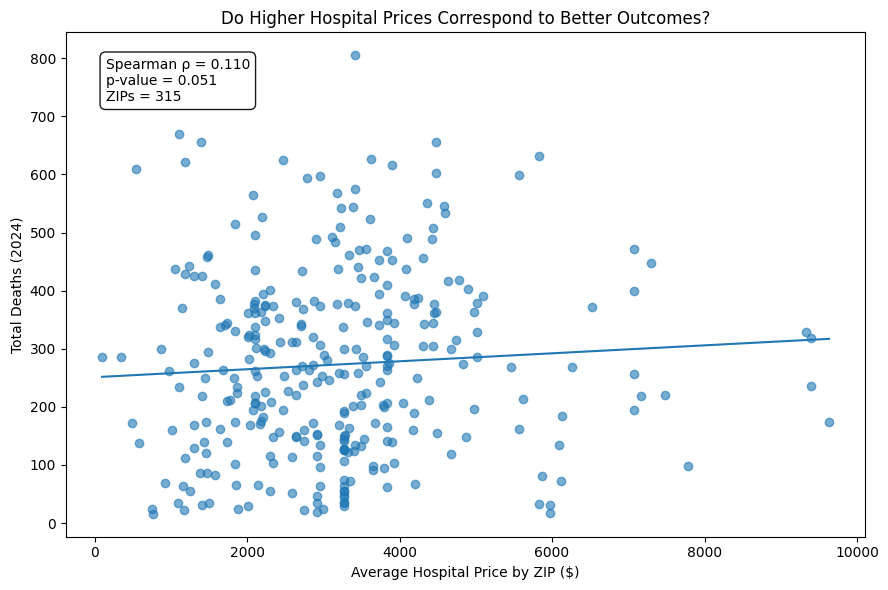

In [20]:
import matplotlib.pyplot as plt
import numpy as np

x = df_final["avg_price"].values
y = df_final["total_deaths"].values

# trend line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b

plt.figure(figsize=(9,6))

plt.scatter(x, y, alpha=0.6)
plt.plot(x_line, y_line)

plt.xlabel("Average Hospital Price by ZIP ($)")
plt.ylabel("Total Deaths (2024)")
plt.title("Do Higher Hospital Prices Correspond to Better Outcomes?")

plt.text(
    0.05, 0.95,
    f"Spearman ρ = {rho:.3f}\np-value = {pval:.3f}\nZIPs = {len(df_final)}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()

In [21]:
#Interpretation 
#The Spearman correlation between average hospital prices and total deaths is weak (ρ ≈ 0.10) and not statistically significant (p > 0.05).
#This suggests that higher-priced hospital areas do not consistently have better health outcomes.
#This is a preliminary ZIP-level analysis using total deaths rather than population-adjusted mortality rates, but the lack of association is notable.